# Multi-Task BERTweet Humor Model

This notebook upgrades the original binary humor classifier into a multi-task humor analysis model.

The model predicts:

1. **Humor detection**: humorous vs not humorous
2. **Humor rating**: how funny the text is, usually 0–5
3. **Offense rating**: how offensive the text is, usually 0–5
4. **Humor controversy**: whether annotators disagreed strongly about the humor label

This uses the SemEval 2021 Task 7 / HaHackathon dataset format.

In [1]:
!pip install -q transformers datasets accelerate evaluate emoji scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 31.1 MB/s eta 0:00:00


## 1. Load the dataset

The notebook clones a public HaHackathon repository containing the SemEval-style CSV files. If the path changes, update `train_path` below.

In [2]:
!git clone -q https://github.com/NLP-UMUTeam/SemEval2021-HaHackathon-UMUTeam.git || true

In [3]:
import os
import pandas as pd
import numpy as np

base_path = "/content/SemEval2021-HaHackathon-UMUTeam"

for root, dirs, files in os.walk(base_path):
    if "dataset" in root.lower():
        print(root)
        for f in files:
            print("  ", f)

/content/SemEval2021-HaHackathon-UMUTeam/datasets
   hahackathon_test.csv
   hahackathon_train.csv
   hahackathon_dev.csv


In [4]:
train_path = "/content/SemEval2021-HaHackathon-UMUTeam/datasets/hahackathon_train.csv"

df_raw = pd.read_csv(train_path)
print(df_raw.shape)
print(df_raw.columns.tolist())
df_raw.head()

(8000, 6)
['id', 'text', 'is_humor', 'humor_rating', 'humor_controversy', 'offense_rating']


,id,text,is_humor,humor_rating,humor_controversy,offense_rating
0,1,TENNESSEE: We're the best state. Nobody even c...,1,2.42,1.0,0.2
1,2,A man inserted an advertisement in the classif...,1,2.50,1.0,1.1
2,3,How many men does it take to open a can of bee...,1,1.95,0.0,2.4
3,4,Told my mom I hit 1200 Twitter followers. She ...,1,2.11,1.0,0.0
4,5,Roses are dead. Love is fake. Weddings are bas...,1,2.78,0.0,0.1


## 2. Prepare multi-task labels

Expected HaHackathon columns are usually:

- `text`
- `is_humor`
- `humor_rating`
- `humor_controversy`
- `offense_rating`

The code below is intentionally defensive so it can handle slight column name variations.

In [5]:
def find_col(possible_names, columns):
    columns_lower = {c.lower(): c for c in columns}
    for name in possible_names:
        if name.lower() in columns_lower:
            return columns_lower[name.lower()]
    raise ValueError(f"Could not find any of these columns: {possible_names}")

text_col = find_col(["text", "sentence", "tweet"], df_raw.columns)
humor_col = find_col(["is_humor", "humor", "label"], df_raw.columns)
humor_rating_col = find_col(["humor_rating", "humor_score", "funniness_average"], df_raw.columns)
offense_rating_col = find_col(["offense_rating", "offense_score"], df_raw.columns)
controversy_col = find_col(["humor_controversy", "controversy", "is_controversial"], df_raw.columns)

print("text:", text_col)
print("humor label:", humor_col)
print("humor rating:", humor_rating_col)
print("offense rating:", offense_rating_col)
print("controversy:", controversy_col)

df = df_raw[[text_col, humor_col, humor_rating_col, offense_rating_col, controversy_col]].copy()
df.columns = ["text", "labels_humor", "labels_humor_rating", "labels_offense_rating", "labels_controversy"]

df["text"] = df["text"].astype(str)
df["labels_humor"] = df["labels_humor"].astype(int)

# Ratings are regression targets. Missing values are allowed and masked during loss computation.
df["labels_humor_rating"] = pd.to_numeric(df["labels_humor_rating"], errors="coerce")
df["labels_offense_rating"] = pd.to_numeric(df["labels_offense_rating"], errors="coerce")

# Controversy may be missing for non-humorous examples. We keep missing values as -100 so CrossEntropy ignores them.
df["labels_controversy"] = pd.to_numeric(df["labels_controversy"], errors="coerce")
df["labels_controversy"] = df["labels_controversy"].fillna(-100).astype(int)

print(df.shape)
print(df[["labels_humor", "labels_humor_rating", "labels_offense_rating", "labels_controversy"]].describe(include="all"))
df.head()

text: text
humor label: is_humor
humor rating: humor_rating
offense rating: offense_rating
controversy: humor_controversy
(8000, 5)
       labels_humor  labels_humor_rating  labels_offense_rating  \
count   8000.000000          4932.000000            8000.000000   
mean       0.616500             2.260525               0.585325   
std        0.486269             0.566974               0.979955   
min        0.000000             0.100000               0.000000   
25%        0.000000             1.890000               0.000000   
50%        1.000000             2.280000               0.100000   
75%        1.000000             2.650000               0.700000   
max        1.000000             4.000000               4.850000   

       labels_controversy  
count         8000.000000  
mean           -38.041875  
std             48.871489  
min           -100.000000  
25%           -100.000000  
50%              0.000000  
75%              1.000000  
max              1.000000  


,text,labels_humor,labels_humor_rating,labels_offense_rating,labels_controversy
0,TENNESSEE: We're the best state. Nobody even c...,1,2.42,0.2,1
1,A man inserted an advertisement in the classif...,1,2.50,1.1,1
2,How many men does it take to open a can of bee...,1,1.95,2.4,0
3,Told my mom I hit 1200 Twitter followers. She ...,1,2.11,0.0,1
4,Roses are dead. Love is fake. Weddings are bas...,1,2.78,0.1,0


In [6]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["labels_humor"]
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Train labels:")
print(train_df["labels_humor"].value_counts())
print("Validation labels:")
print(val_df["labels_humor"].value_counts())

Train: (6400, 5)
Validation: (1600, 5)
Train labels:
labels_humor
1    3946
0    2454
Name: count, dtype: int64
Validation labels:
labels_humor
1    986
0    614
Name: count, dtype: int64


## 3. Tokenize with BERTweet

In [7]:
import torch
from datasets import Dataset
from transformers import AutoTokenizer

model_name = "vinai/bertweet-base"

tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    use_fast=False,
    normalization=True
)

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True))

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

columns = [
    "input_ids", "attention_mask",
    "labels_humor", "labels_humor_rating", "labels_offense_rating", "labels_controversy"
]

train_dataset.set_format(type="torch", columns=columns)
val_dataset.set_format(type="torch", columns=columns)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/843k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.91M [00:00<?, ?B/s]

Map:   0%|          | 0/6400 [00:00<?, ? examples/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

## 4. Define a multi-task BERTweet model

The BERTweet encoder is shared, while each task has its own prediction head.

In [10]:
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel, PreTrainedModel, AutoConfig
from transformers.modeling_outputs import SequenceClassifierOutput

class BertweetMultiTaskModel(PreTrainedModel):
    config_class = AutoConfig

    def __init__(self, config):
        super().__init__(config)
        self.bertweet = AutoModel.from_pretrained(model_name, config=config)
        hidden_size = config.hidden_size
        dropout_prob = getattr(config, "hidden_dropout_prob", 0.1)

        self.dropout = nn.Dropout(dropout_prob)
        self.humor_classifier = nn.Linear(hidden_size, 2)
        self.controversy_classifier = nn.Linear(hidden_size, 2)
        self.humor_regressor = nn.Linear(hidden_size, 1)
        self.offense_regressor = nn.Linear(hidden_size, 1)

        self.post_init()

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        labels_humor=None,
        labels_humor_rating=None,
        labels_offense_rating=None,
        labels_controversy=None,
        **kwargs
    ):
        outputs = self.bertweet(
            input_ids=input_ids,
            attention_mask=attention_mask,
            **kwargs
        )

        # RoBERTa/BERTweet: first token representation is used like CLS.
        pooled = outputs.last_hidden_state[:, 0, :]
        pooled = self.dropout(pooled)

        logits_humor = self.humor_classifier(pooled)
        logits_controversy = self.controversy_classifier(pooled)
        pred_humor_rating = self.humor_regressor(pooled).squeeze(-1)
        pred_offense_rating = self.offense_regressor(pooled).squeeze(-1)

        loss = None
        losses = []

        if labels_humor is not None:
            losses.append(F.cross_entropy(logits_humor, labels_humor.long()))

        if labels_humor_rating is not None:
            mask = ~torch.isnan(labels_humor_rating.float())
            if mask.any():
                losses.append(F.mse_loss(pred_humor_rating[mask], labels_humor_rating.float()[mask]))

        if labels_offense_rating is not None:
            mask = ~torch.isnan(labels_offense_rating.float())
            if mask.any():
                losses.append(F.mse_loss(pred_offense_rating[mask], labels_offense_rating.float()[mask]))

        if labels_controversy is not None:
            mask = labels_controversy != -100
            if mask.any():
                losses.append(F.cross_entropy(logits_controversy[mask], labels_controversy.long()[mask]))

        if losses:
            loss = sum(losses)

        # Trainer expects one "logits" object. We return a tuple with all task outputs.
        return SequenceClassifierOutput(
            loss=loss,
            logits=(logits_humor, pred_humor_rating, pred_offense_rating, logits_controversy),
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions
        )

In [15]:
import sys
from pathlib import Path

Path("/content/notebook.py").write_text("# dummy file for transformers notebook compatibility\n")

sys.modules["__main__"].__file__ = "/content/notebook.py"

In [16]:
from transformers import AutoConfig

config = AutoConfig.from_pretrained(model_name)
model = BertweetMultiTaskModel(config)

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/bertweet-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.bias                    | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 5. Metrics

Classification tasks use accuracy/F1. Regression tasks use RMSE and MAE.

In [17]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, mean_squared_error, mean_absolute_error


def safe_rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    logits_humor, pred_humor_rating, pred_offense_rating, logits_controversy = predictions
    labels_humor, labels_humor_rating, labels_offense_rating, labels_controversy = labels

    humor_pred = np.argmax(logits_humor, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels_humor,
        humor_pred,
        average="binary",
        zero_division=0
    )

    metrics = {
        "humor_accuracy": accuracy_score(labels_humor, humor_pred),
        "humor_precision": precision,
        "humor_recall": recall,
        "humor_f1": f1,
    }

    humor_mask = ~np.isnan(labels_humor_rating.astype(float))
    if humor_mask.any():
        metrics["humor_rating_rmse"] = safe_rmse(labels_humor_rating[humor_mask], pred_humor_rating[humor_mask])
        metrics["humor_rating_mae"] = mean_absolute_error(labels_humor_rating[humor_mask], pred_humor_rating[humor_mask])

    offense_mask = ~np.isnan(labels_offense_rating.astype(float))
    if offense_mask.any():
        metrics["offense_rating_rmse"] = safe_rmse(labels_offense_rating[offense_mask], pred_offense_rating[offense_mask])
        metrics["offense_rating_mae"] = mean_absolute_error(labels_offense_rating[offense_mask], pred_offense_rating[offense_mask])

    controversy_mask = labels_controversy != -100
    if controversy_mask.any():
        controversy_pred = np.argmax(logits_controversy[controversy_mask], axis=-1)
        c_precision, c_recall, c_f1, _ = precision_recall_fscore_support(
            labels_controversy[controversy_mask],
            controversy_pred,
            average="binary",
            zero_division=0
        )
        metrics["controversy_accuracy"] = accuracy_score(labels_controversy[controversy_mask], controversy_pred)
        metrics["controversy_f1"] = c_f1

    return metrics

## 6. Train

This is heavier than the binary model because the model optimizes four tasks at once. For a first run, 3 epochs is enough.

In [19]:
import sys
import datasets.config

# Prevent HuggingFace datasets from trying to use torchvision video/image helpers
datasets.config.TORCHVISION_AVAILABLE = False

# Optional: remove torchvision from already-loaded modules
for module_name in list(sys.modules.keys()):
    if module_name.startswith("torchvision"):
        del sys.modules[module_name]

In [20]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./bertweet-multitask-humor-model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="humor_f1",
    greater_is_better=True,
    logging_dir="./logs",
    logging_steps=50,
    report_to="none",
    label_names=[
        "labels_humor",
        "labels_humor_rating",
        "labels_offense_rating",
        "labels_controversy"
    ]
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Humor Accuracy,Humor Precision,Humor Recall,Humor F1,Humor Rating Rmse,Humor Rating Mae,Offense Rating Rmse,Offense Rating Mae,Controversy Accuracy,Controversy F1
1,1.576234,1.447050,0.948125,0.954683,0.961460,0.958060,0.519437,0.408030,0.578989,0.366427,0.566937,0.526082
2,1.260286,1.377456,0.954375,0.981033,0.944219,0.962274,0.501810,0.398827,0.548677,0.325850,0.540568,0.595174
3,1.141936,1.380157,0.959375,0.968464,0.965517,0.966988,0.511445,0.403995,0.548195,0.323383,0.557809,0.610714


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1200, training_loss=1.4822933387756347, metrics={'train_runtime': 530.2724, 'train_samples_per_second': 36.208, 'train_steps_per_second': 2.263, 'total_flos': 1262978423193600.0, 'train_loss': 1.4822933387756347, 'epoch': 3.0})

In [21]:
eval_results = trainer.evaluate()
eval_results

{'eval_loss': 1.3801568746566772,
 'eval_humor_accuracy': 0.959375,
 'eval_humor_precision': 0.9684638860630722,
 'eval_humor_recall': 0.9655172413793104,
 'eval_humor_f1': 0.9669883189436262,
 'eval_humor_rating_rmse': 0.5114447172984966,
 'eval_humor_rating_mae': 0.4039950668811798,
 'eval_offense_rating_rmse': 0.5481954165282725,
 'eval_offense_rating_mae': 0.3233829438686371,
 'eval_controversy_accuracy': 0.5578093306288032,
 'eval_controversy_f1': 0.6107142857142858,
 'eval_runtime': 13.9137,
 'eval_samples_per_second': 114.995,
 'eval_steps_per_second': 7.187,
 'epoch': 3.0}

## 7. Detailed evaluation and confusion matrix

              precision    recall  f1-score   support

Not humorous       0.94      0.95      0.95       614
    Humorous       0.97      0.97      0.97       986

    accuracy                           0.96      1600
   macro avg       0.96      0.96      0.96      1600
weighted avg       0.96      0.96      0.96      1600



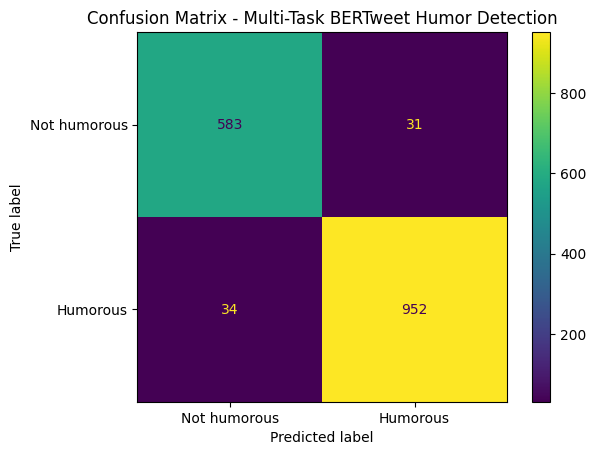

In [22]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

pred_output = trainer.predict(val_dataset)
logits_humor, pred_humor_rating, pred_offense_rating, logits_controversy = pred_output.predictions
labels_humor, labels_humor_rating, labels_offense_rating, labels_controversy = pred_output.label_ids

y_pred = np.argmax(logits_humor, axis=-1)

print(classification_report(
    labels_humor,
    y_pred,
    target_names=["Not humorous", "Humorous"],
    zero_division=0
))

cm = confusion_matrix(labels_humor, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Not humorous", "Humorous"])
disp.plot()
plt.title("Confusion Matrix - Multi-Task BERTweet Humor Detection")
plt.show()

In [23]:
# Regression sanity checks
results_df = val_df.reset_index(drop=True).copy()
results_df["pred_humor_label"] = y_pred
results_df["pred_humor_rating"] = pred_humor_rating
results_df["pred_offense_rating"] = pred_offense_rating
results_df["pred_controversy"] = np.argmax(logits_controversy, axis=-1)

results_df[[
    "text",
    "labels_humor",
    "pred_humor_label",
    "labels_humor_rating",
    "pred_humor_rating",
    "labels_offense_rating",
    "pred_offense_rating",
    "labels_controversy",
    "pred_controversy"
]].head(10)

,text,labels_humor,pred_humor_label,labels_humor_rating,pred_humor_rating,labels_offense_rating,pred_offense_rating,labels_controversy,pred_controversy
0,Mango helps clearing clogged pores that causes...,0,0,NaN,1.138739,0.00,0.059583,-100,0
1,What do you call an apology written in dots an...,1,1,2.90,2.459551,0.00,0.103203,0,1
2,A woman wakes up after a vaginal tuck to find ...,1,1,2.68,2.471237,1.00,0.873266,1,1
3,"""I swear you're giving me a heart attack."" - O...",0,0,NaN,1.255711,0.05,-0.111061,-100,0
4,Surround yourself with people who are exactly ...,0,0,NaN,1.209189,0.00,0.010322,-100,0
5,Scarcity mentality is a mental disorder that c...,0,0,NaN,1.258071,0.00,0.176359,-100,0
6,What sound does a gay magician make when he di...,1,1,1.80,2.089009,2.55,2.262196,1,1
7,Why do all Asians think they're a celebrity in...,1,1,1.00,2.114578,3.05,2.407702,0,0
8,"Mer: ""I don't want you to date other people. I...",0,0,NaN,1.150180,0.05,0.048680,-100,0
9,I broke up with my girlfriend because she woul...,1,1,2.95,3.018214,0.05,0.273669,0,0


## 8. Inference function

This produces a more impressive output than the old binary classifier.

In [24]:
def predict_multitask(text):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        logits_humor, pred_humor_rating, pred_offense_rating, logits_controversy = outputs.logits
        humor_probs = torch.softmax(logits_humor, dim=-1)[0]
        controversy_probs = torch.softmax(logits_controversy, dim=-1)[0]

    humor_label_id = int(torch.argmax(humor_probs).item())
    controversy_id = int(torch.argmax(controversy_probs).item())

    humor_score = float(pred_humor_rating[0].item())
    offense_score = float(pred_offense_rating[0].item())

    # Keep ratings in the expected human-interpretable range.
    humor_score = max(0.0, min(5.0, humor_score))
    offense_score = max(0.0, min(5.0, offense_score))

    return {
        "label": "Humorous" if humor_label_id == 1 else "Not humorous",
        "confidence": float(humor_probs[humor_label_id].item()),
        "not_humorous_probability": float(humor_probs[0].item()),
        "humorous_probability": float(humor_probs[1].item()),
        "humor_rating_0_to_5": round(humor_score, 2),
        "offense_rating_0_to_5": round(offense_score, 2),
        "controversial": bool(controversy_id),
        "controversy_probability": float(controversy_probs[1].item())
    }

In [25]:
examples = [
    "I used to play piano by ear, but now I use my hands.",
    "The database backup completed successfully.",
    "My cat looked at the expensive food I bought and decided starvation was more dignified.",
    "I told my computer I needed a break, and now it won't stop sending me vacation ads.",
]

for ex in examples:
    print(ex)
    print(predict_multitask(ex))
    print("-" * 70)

I used to play piano by ear, but now I use my hands.
{'label': 'Humorous', 'confidence': 0.9755776524543762, 'not_humorous_probability': 0.02442232333123684, 'humorous_probability': 0.9755776524543762, 'humor_rating_0_to_5': 2.98, 'offense_rating_0_to_5': 0.01, 'controversial': False, 'controversy_probability': 0.46064701676368713}
----------------------------------------------------------------------
The database backup completed successfully.
{'label': 'Not humorous', 'confidence': 0.9593757390975952, 'not_humorous_probability': 0.9593757390975952, 'humorous_probability': 0.04062427580356598, 'humor_rating_0_to_5': 1.73, 'offense_rating_0_to_5': 0.11, 'controversial': False, 'controversy_probability': 0.37832483649253845}
----------------------------------------------------------------------
My cat looked at the expensive food I bought and decided starvation was more dignified.
{'label': 'Humorous', 'confidence': 0.988436222076416, 'not_humorous_probability': 0.011563800275325775, 'h

## 9. Save model for later use

Because this is a custom multi-task architecture, save both the tokenizer and model state dictionary.

In [26]:
save_path = "./bertweet_multitask_humor_model"
os.makedirs(save_path, exist_ok=True)

tokenizer.save_pretrained(save_path)
model.config.save_pretrained(save_path)
torch.save(model.state_dict(), os.path.join(save_path, "multitask_model_state.pt"))

print("Saved to", save_path)

Saved to ./bertweet_multitask_humor_model


In [27]:
!zip -r bertweet_multitask_humor_model.zip bertweet_multitask_humor_model

try:
    from google.colab import files
    files.download("bertweet_multitask_humor_model.zip")
except Exception as e:
    print("Download manually from the Colab file browser:", e)

  adding: bertweet_multitask_humor_model/ (stored 0%)
  adding: bertweet_multitask_humor_model/added_tokens.json (stored 0%)
  adding: bertweet_multitask_humor_model/vocab.txt (deflated 50%)
  adding: bertweet_multitask_humor_model/multitask_model_state.pt (deflated 13%)
  adding: bertweet_multitask_humor_model/bpe.codes (deflated 57%)
  adding: bertweet_multitask_humor_model/config.json (deflated 51%)
  adding: bertweet_multitask_humor_model/tokenizer_config.json (deflated 76%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>